In [1]:
"""
================================================================================================
NOTEBOOK 02: Model Training & Evaluation
================================================================================================
Author: Mary Wangoi Mwangi (122174)
================================================================================================
Goal:
    Build, train, and evaluate three machine learning classification models on the
    cleaned RTA dataset to classify accident severity into High-Severity and Low-Severity.

Key Actions:
    1. Load the cleaned labeled dataset from Notebook 01
    2. Define features (X) and target variable (y)
    3. Apply stratified 70/15/15 train/validation/test split
    4. Build sklearn pipelines with preprocessing and classifiers
    5. Apply SMOTE on training set only to handle class imbalance
    6. Train Logistic Regression (baseline), Random Forest, and XGBoost
    7. Evaluate all three models using 5-fold cross-validation
    8. Generate confusion matrices and classification reports

Outcome:
    Trained models saved to models/ folder ready for statistical
    testing and ensemble creation in Notebook 03.
================================================================================================
"""

# ============================================================
# SECTION 1: LIBRARY IMPORTS & GLOBAL CONFIGURATION
# Load all required libraries for model training and evaluation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # Data splitting & cross-validation
from sklearn.preprocessing import LabelEncoder # Encode categorical features to numbers
from sklearn.pipeline import Pipeline   # Chain preprocessing and model steps
from sklearn.linear_model import LogisticRegression   # Baseline classifier
from sklearn.ensemble import RandomForestClassifier  # Ensemble tree-based classifier
from sklearn.metrics import (classification_report, confusion_matrix,  # Model evaluation metrics
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE  # Handle class imbalance
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline that supports SMOTE
from xgboost import XGBClassifier # High-performance gradient boosting classifier
import joblib # Save and load trained models

warnings.filterwarnings('ignore')

# Reproducibility seed
SEED = 42

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")
print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
print(f"   sklearn     : {__import__('sklearn').__version__}")
print(f"   xgboost     : {__import__('xgboost').__version__}")
print(f"   imbalanced  : {__import__('imblearn').__version__}")

Libraries loaded successfully.
   pandas      : 2.3.3
   numpy       : 2.4.3
   sklearn     : 1.8.0
   xgboost     : 3.2.0
   imbalanced  : 0.14.1


In [2]:
# ============================================================
# SECTION 2: DATA LOADING & FEATURE DEFINITION
# Load cleaned dataset and define features (X) and target (y)
# ============================================================

# Load the cleaned labeled dataset from Notebook 01
data_path = '../data/processed/rta_accidents_labeled.csv'
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

# ---- Define Target Variable (y) ----
y = df['Severity_Class']

# ---- Define Feature Matrix (X) ----
# Drop target, and columns not useful for modeling:
# - Casualty_severity : post-incident medical outcome, not available at dispatch time
# - Casualty_class    : describes victim type, recorded after incident
# - Sex_of_casualty   : recorded after incident
# - Age_band_of_casualty : recorded after incident
# - Work_of_casuality : recorded after incident
# - Fitness_of_casuality : recorded after incident

drop_cols = [
    'Severity_Class',
    'Casualty_severity',
    'Casualty_class',
    'Sex_of_casualty',
    'Age_band_of_casualty',
    'Work_of_casuality',
    'Fitness_of_casuality',
]

X = df.drop(columns=drop_cols)

print(f"\n Feature matrix (X) shape : {X.shape}")
print(f"Target vector (y) shape  : {y.shape}")
print(f"\n Features used for modeling ({X.shape[1]}):")
for col in X.columns.tolist():
    print(f"   - {col}")

print(f"\n Target distribution:")
print(y.value_counts())

Dataset loaded successfully.
   Rows    : 12,316
   Columns : 32

 Feature matrix (X) shape : (12316, 25)
Target vector (y) shape  : (12316,)

 Features used for modeling (25):
   - Time
   - Day_of_week
   - Age_band_of_driver
   - Sex_of_driver
   - Educational_level
   - Vehicle_driver_relation
   - Driving_experience
   - Type_of_vehicle
   - Owner_of_vehicle
   - Service_year_of_vehicle
   - Defect_of_vehicle
   - Area_accident_occured
   - Lanes_or_Medians
   - Road_allignment
   - Types_of_Junction
   - Road_surface_type
   - Road_surface_conditions
   - Light_conditions
   - Weather_conditions
   - Type_of_collision
   - Number_of_vehicles_involved
   - Number_of_casualties
   - Vehicle_movement
   - Pedestrian_movement
   - Cause_of_accident

 Target distribution:
Severity_Class
0    10415
1     1901
Name: count, dtype: int64


In [3]:
# ============================================================
# SECTION 3: FEATURE ENGINEERING
# Extract meaningful features from Time and Day_of_week
# ============================================================

X = X.copy()

# ---- Extract Hour_of_day from Time column ----
X['Hour_of_day'] = pd.to_datetime(X['Time'], format='%H:%M:%S').dt.hour

# ---- Engineer Is_night flag ----
# Night defined as 20:00 - 05:00 (high risk period)
X['Is_night'] = X['Hour_of_day'].apply(lambda h: 1 if (h >= 20 or h <= 5) else 0)

# ---- Engineer Is_rush_hour flag ----
# Rush hour: Morning 07:00-09:00 or Evening 17:00-19:00
X['Is_rush_hour'] = X['Hour_of_day'].apply(lambda h: 1 if (7 <= h <= 9 or 17 <= h <= 19) else 0)

# ---- Engineer Is_weekend flag ----
# Weekend: Saturday and Sunday
X['Is_weekend'] = X['Day_of_week'].apply(lambda d: 1 if d in ['Saturday', 'Sunday'] else 0)

# ---- Drop raw Time column (replaced by engineered features) ----
X = X.drop(columns=['Time'])

print("Feature engineering complete.")
print(f"   Extracted  : Hour_of_day from Time")
print(f"   Engineered : Is_night, Is_rush_hour, Is_weekend")
print(f"   Dropped    : Time (raw string)")
print(f"\nUpdated feature matrix shape : {X.shape}")

print(f"\nEngineered feature distributions:")
print(f"   Is_night     : {X['Is_night'].sum():,} night records ({X['Is_night'].mean()*100:.1f}%)")
print(f"   Is_rush_hour : {X['Is_rush_hour'].sum():,} rush hour records ({X['Is_rush_hour'].mean()*100:.1f}%)")
print(f"   Is_weekend   : {X['Is_weekend'].sum():,} weekend records ({X['Is_weekend'].mean()*100:.1f}%)")

print(f"\nUpdated features ({X.shape[1]}):")
for col in X.columns.tolist():
    print(f"   - {col}")

Feature engineering complete.
   Extracted  : Hour_of_day from Time
   Engineered : Is_night, Is_rush_hour, Is_weekend
   Dropped    : Time (raw string)

Updated feature matrix shape : (12316, 28)

Engineered feature distributions:
   Is_night     : 2,291 night records (18.6%)
   Is_rush_hour : 4,811 rush hour records (39.1%)
   Is_weekend   : 3,133 weekend records (25.4%)

Updated features (28):
   - Day_of_week
   - Age_band_of_driver
   - Sex_of_driver
   - Educational_level
   - Vehicle_driver_relation
   - Driving_experience
   - Type_of_vehicle
   - Owner_of_vehicle
   - Service_year_of_vehicle
   - Defect_of_vehicle
   - Area_accident_occured
   - Lanes_or_Medians
   - Road_allignment
   - Types_of_Junction
   - Road_surface_type
   - Road_surface_conditions
   - Light_conditions
   - Weather_conditions
   - Type_of_collision
   - Number_of_vehicles_involved
   - Number_of_casualties
   - Vehicle_movement
   - Pedestrian_movement
   - Cause_of_accident
   - Hour_of_day
   - Is_n

In [4]:
# ============================================================
# SECTION 4: STRATIFIED DATA SPLITTING
# Split into Train (70%), Validation (15%) and Test (15%)
# Encoding will be handled inside the pipeline to prevent leakage
# scale_pos_weight calculated here for use in pipeline construction
# ============================================================

# ---- Stratified 70/15/15 Split ----
# Step 1: Split into 70% train and 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Step 2: Split temp into 50/50 — giving 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# ---- Calculate scale_pos_weight for XGBoost ----
# Ratio of negative to positive class in training set
# Defined here so it is available for pipeline construction in Cell 5
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

print("Stratified 70/15/15 split complete.")
print(f"   Training   (70%) : {X_train.shape[0]:,} rows")
print(f"   Validation (15%) : {X_val.shape[0]:,} rows")
print(f"   Test       (15%) : {X_test.shape[0]:,} rows")
print(f"\nClass distribution after split:")
print(f"   Train - High-Severity : {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"   Val   - High-Severity : {y_val.sum():,} ({y_val.mean()*100:.1f}%)")
print(f"   Test  - High-Severity : {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"\nXGBoost scale_pos_weight : {scale_pos:.2f}")

Stratified 70/15/15 split complete.
   Training   (70%) : 8,621 rows
   Validation (15%) : 1,847 rows
   Test       (15%) : 1,848 rows

Class distribution after split:
   Train - High-Severity : 1,331 (15.4%)
   Val   - High-Severity : 285 (15.4%)
   Test  - High-Severity : 285 (15.4%)

XGBoost scale_pos_weight : 5.48


In [5]:
# ============================================================
# SECTION 5: PIPELINE CONSTRUCTION
# Build pipelines for each model with preprocessing inside
#
# Key design decisions:
#   LR  : SelectKBest(k=40) — statistical selection suits linear model
#          SMOTETomek — works well with linear models
#          class_weight balanced — handles imbalance
#
#   RF  : SelectFromModel(max_features=40) — model-based selection
#          No SMOTE — BalancedRF handles imbalance internally
#
#   XGB : SelectFromModel(max_features=40) — model-based selection
#          No SMOTE — scale_pos_weight handles imbalance
#          Double weighting (SMOTE + scale_pos_weight) removed
#          Regularization added to reduce false positives
# ============================================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from imblearn.combine import SMOTETomek

# ---- Identify categorical and numeric columns ----
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=['int64',
                                          'float64']).columns.tolist()

print(f"Categorical columns : {len(cat_cols)}")
print(f"Numeric columns     : {len(num_cols)}")

# ---- Preprocessor factory functions ----
# Using functions to create fresh instances per pipeline
# Prevents any cross-contamination between models
def make_preprocessor_base():
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ])

def make_preprocessor_lr():
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

# ---- Feature selector factory for RF and XGBoost ----
# max_features=40 aggressively reduces from 184 to 40
# Removes noisy OneHot columns that hurt precision
def make_xgb_selector():
    return SelectFromModel(
        XGBClassifier(n_estimators=100,
                      random_state=SEED,
                      eval_metric='logloss'),
        max_features=40
    )

# ---- Pipeline 1: Logistic Regression ----
# SelectKBest — statistical feature selection suits linear models
# SMOTETomek — works well with linear models, cleans boundary
# class_weight balanced — handles imbalance at model level
pipeline_lr = ImbPipeline([
    ('preprocessor', make_preprocessor_lr()),
    ('feature_selection', SelectKBest(f_classif, k=40)),
    ('smote', SMOTETomek(random_state=SEED)),
    ('classifier', LogisticRegression(random_state=SEED,
                                      max_iter=2000,
                                      class_weight='balanced'))
])

# ---- Pipeline 2: Balanced Random Forest ----
# SelectFromModel — model-based selection
# No SMOTE — BalancedRF handles imbalance internally
# Adding SMOTE would double-count imbalance handling
pipeline_rf = ImbPipeline([
    ('preprocessor', make_preprocessor_base()),
    ('feature_selection', make_xgb_selector()),
    ('classifier', BalancedRandomForestClassifier(
        random_state=SEED,
        sampling_strategy='auto',
        replacement=True
    ))
])

# ---- Pipeline 3: XGBoost ----
# SelectFromModel — model-based selection
# NO SMOTE — scale_pos_weight handles imbalance at gradient level
# SMOTE + scale_pos_weight = double weighting = precision collapse
# Regularization added: gamma, reg_alpha, reg_lambda reduce false positives
pipeline_xgb = ImbPipeline([
    ('preprocessor', make_preprocessor_base()),
    ('feature_selection', make_xgb_selector()),
    ('classifier', XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.6,
        gamma=1,
        reg_alpha=1,
        reg_lambda=2,
        max_delta_step=1
    ))
])

print("\nPipelines constructed successfully.")
print("   Pipeline 1 : LR  — OHE + Scaling + SelectKBest(40)"
      " + SMOTETomek + LR")
print("   Pipeline 2 : RF  — OHE + SelectFromModel(40) + BalancedRF")
print("   Pipeline 3 : XGB — OHE + SelectFromModel(40) + XGB")
print(f"\nKey design decisions:")
print(f"   LR  : SMOTETomek kept — works well with linear models")
print(f"   RF  : No SMOTE — BalancedRF handles imbalance internally")
print(f"   XGB : No SMOTE — scale_pos_weight only, no double weighting")
print(f"   All : Feature reduction from 184 to 40 — removes noise")

Categorical columns : 22
Numeric columns     : 5

Pipelines constructed successfully.
   Pipeline 1 : LR  — OHE + Scaling + SelectKBest(40) + SMOTETomek + LR
   Pipeline 2 : RF  — OHE + SelectFromModel(40) + BalancedRF
   Pipeline 3 : XGB — OHE + SelectFromModel(40) + XGB

Key design decisions:
   LR  : SMOTETomek kept — works well with linear models
   RF  : No SMOTE — BalancedRF handles imbalance internally
   XGB : No SMOTE — scale_pos_weight only, no double weighting
   All : Feature reduction from 184 to 40 — removes noise


In [6]:
# ============================================================
# SECTION 6: MODEL TRAINING & CROSS-VALIDATION
# Train all 3 models and evaluate using 5-fold cross-validation
# Primary metric: Recall for High-Severity class
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Metrics to evaluate
scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

models = {
    'Logistic Regression' : pipeline_lr,
    'Random Forest'       : pipeline_rf,
    'XGBoost'             : pipeline_xgb
}

cv_results = {}

print("Running 5-Fold Cross-Validation on training set...")
print("="*55)

for name, pipeline in models.items():
    print(f"\nTraining {name}...")
    results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_results[name] = results
    print(f"   Recall    : {results['test_recall'].mean():.3f} (+/- {results['test_recall'].std():.3f})")
    print(f"   Precision : {results['test_precision'].mean():.3f} (+/- {results['test_precision'].std():.3f})")
    print(f"   F1 Score  : {results['test_f1'].mean():.3f} (+/- {results['test_f1'].std():.3f})")
    print(f"   ROC AUC   : {results['test_roc_auc'].mean():.3f} (+/- {results['test_roc_auc'].std():.3f})")

print("\n" + "="*55)
print("Cross-validation complete.")

Running 5-Fold Cross-Validation on training set...

Training Logistic Regression...
   Recall    : 0.560 (+/- 0.030)
   Precision : 0.195 (+/- 0.008)
   F1 Score  : 0.290 (+/- 0.012)
   ROC AUC   : 0.591 (+/- 0.017)

Training Random Forest...
   Recall    : 0.605 (+/- 0.014)
   Precision : 0.213 (+/- 0.005)
   F1 Score  : 0.315 (+/- 0.007)
   ROC AUC   : 0.637 (+/- 0.009)

Training XGBoost...
   Recall    : 0.460 (+/- 0.036)
   Precision : 0.245 (+/- 0.003)
   F1 Score  : 0.320 (+/- 0.008)
   ROC AUC   : 0.639 (+/- 0.008)

Cross-validation complete.


In [19]:
# ============================================================
# SECTION 7: HYPERPARAMETER TUNING
# Use GridSearchCV for LR and XGBoost (small grids)
# RandomizedSearchCV for RF (large grid — faster)
# Optimising for Recall — primary metric for emergency dispatch
#
# Steps:
#   1. Parameter grids focus on classifier parameters only
#      Preprocessing and feature selection fixed in Cell 5
#   2. Run GridSearchCV/RandomizedSearchCV with 5-fold CV
#   3. Report best Recall and best parameters per model
# ============================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

print(f"XGBoost scale_pos_weight : {scale_pos:.2f}")

# ---- Parameter grids ----
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga']
}

param_dist_rf = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8],
    'classifier__colsample_bytree': [0.6, 0.8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("\nRunning Hyperparameter Tuning...")
print("="*55)

# Logistic Regression
print("\nTuning Logistic Regression...")
gs_lr = GridSearchCV(pipeline_lr, param_grid_lr,
                     cv=cv, scoring='recall',
                     n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)
print(f"   Best Recall : {gs_lr.best_score_:.3f}")
print(f"   Best Params : {gs_lr.best_params_}")

# Balanced Random Forest
print("\nTuning Balanced Random Forest...")
gs_rf = RandomizedSearchCV(pipeline_rf, param_dist_rf,
                            n_iter=20,
                            cv=cv, scoring='recall',
                            random_state=SEED,
                            n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
print(f"   Best Recall : {gs_rf.best_score_:.3f}")
print(f"   Best Params : {gs_rf.best_params_}")

# XGBoost
print("\nTuning XGBoost...")
gs_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb,
                      cv=cv, scoring='recall',
                      n_jobs=-1, verbose=0)
gs_xgb.fit(X_train, y_train)
print(f"   Best Recall : {gs_xgb.best_score_:.3f}")
print(f"   Best Params : {gs_xgb.best_params_}")

# NOTE ON INTERPRETATION OF CV SCORES:
# GridSearchCV reports mean cross-validation Recall scores computed on held-out training folds during hyperparameter search.
# These scores reflect average performance across 5 different data splits during training.
# Validation set scores reported in Cell 8 are from the best estimator retrained on the FULL training set using optimal parameters 
# These are typically higher because:
#   1. Model trained on more data (full training set vs folds)
#   2. Best hyperparameters applied consistently
#   3. Evaluated on truly held-out validation data

# This is expected behaviour and does not indicate overfitting.
# Final performance is assessed on the test set in Notebook 03.


print("\n" + "="*55)
print("Hyperparameter tuning complete.")
print(f"\nSummary:")
print(f"   Logistic Regression    : {gs_lr.best_score_:.3f} Recall")
print(f"   Balanced Random Forest : {gs_rf.best_score_:.3f} Recall")
print(f"   XGBoost                : {gs_xgb.best_score_:.3f} Recall")

XGBoost scale_pos_weight : 5.48

Running Hyperparameter Tuning...

Tuning Logistic Regression...
   Best Recall : 0.607
   Best Params : {'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Tuning Balanced Random Forest...
   Best Recall : 0.597
   Best Params : {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None}

Tuning XGBoost...
   Best Recall : 0.499
   Best Params : {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 300, 'classifier__subsample': 0.7}

Hyperparameter tuning complete.

Summary:
   Logistic Regression    : 0.607 Recall
   Balanced Random Forest : 0.597 Recall
   XGBoost                : 0.499 Recall


In [15]:
# ============================================================
# SECTION 8: VALIDATION SET EVALUATION & THRESHOLD ANALYSIS
# Evaluate tuned models on validation set at default threshold
# Full threshold search from 0.05 to 0.65 in 0.05 increments
# Optimal thresholds determined via granular search in Cell 10
# ============================================================

from sklearn.metrics import (recall_score, precision_score,
                             f1_score, ConfusionMatrixDisplay)

# ---- Get best estimators from GridSearchCV ----
best_lr  = gs_lr.best_estimator_
best_rf  = gs_rf.best_estimator_
best_xgb = gs_xgb.best_estimator_

models_tuned = {
    'Logistic Regression'    : best_lr,
    'Balanced Random Forest' : best_rf,
    'XGBoost'                : best_xgb
}

# ---- Step 1: Default threshold 0.50 ----
print("VALIDATION SET — DEFAULT THRESHOLD (0.50)")
print("="*55)

val_probas       = {}
val_results_050  = {}

for name, model in models_tuned.items():
    y_val_pred  = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    val_probas[name] = y_val_proba

    val_results_050[name] = {
        'Recall'    : recall_score(y_val, y_val_pred),
        'Precision' : precision_score(y_val, y_val_pred),
        'F1'        : f1_score(y_val, y_val_pred),
        'ROC_AUC'   : roc_auc_score(y_val, y_val_proba)
    }

    print(f"\n{name}:")
    print(f"   Recall    : {val_results_050[name]['Recall']:.3f}")
    print(f"   Precision : {val_results_050[name]['Precision']:.3f}")
    print(f"   F1 Score  : {val_results_050[name]['F1']:.3f}")
    print(f"   ROC AUC   : {val_results_050[name]['ROC_AUC']:.3f}")

# ---- Step 2: Threshold search 0.05 to 0.65 ----
print(f"\n{'='*55}")
print("THRESHOLD ANALYSIS (0.05 to 0.65)")
print("="*55)

thresholds = np.arange(0.05, 0.66, 0.05)

for name in models_tuned.keys():
    y_val_proba = val_probas[name]
    print(f"\n{name}:")
    print(f"   {'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10}")
    print(f"   {'-'*44}")
    for thresh in thresholds:
        y_pred = (y_val_proba >= thresh).astype(int)
        if y_pred.sum() == 0:
            continue
        rec  = recall_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        f1   = f1_score(y_val, y_pred)
        print(f"   {thresh:<12.2f} {rec:<10.3f} {prec:<12.3f} {f1:<10.3f}")

# ---- Step 3: Summary at default threshold ----
print(f"\n{'='*55}")
print("PERFORMANCE SUMMARY AT DEFAULT THRESHOLD (0.50)")
print("Note: Optimal thresholds determined via granular")
print("      search in Cell 10 — applied in Cell 11")
print("="*55)
summary_df = pd.DataFrame(val_results_050).T
print(summary_df.round(3).to_string())

VALIDATION SET — DEFAULT THRESHOLD (0.50)

Logistic Regression:
   Recall    : 0.596
   Precision : 0.200
   F1 Score  : 0.299
   ROC AUC   : 0.603

Balanced Random Forest:
   Recall    : 0.663
   Precision : 0.248
   F1 Score  : 0.361
   ROC AUC   : 0.714

XGBoost:
   Recall    : 0.547
   Precision : 0.279
   F1 Score  : 0.370
   ROC AUC   : 0.699

THRESHOLD ANALYSIS (0.05 to 0.65)

Logistic Regression:
   Threshold    Recall     Precision    F1        
   --------------------------------------------
   0.05         1.000      0.154        0.267     
   0.10         1.000      0.154        0.267     
   0.15         1.000      0.154        0.267     
   0.20         1.000      0.154        0.268     
   0.25         0.996      0.155        0.268     
   0.30         0.989      0.155        0.268     
   0.35         0.975      0.159        0.273     
   0.40         0.916      0.162        0.275     
   0.45         0.772      0.177        0.288     
   0.50         0.596      0.200  

Total features after OneHotEncoding  : 184
Features selected by SelectFromModel : 40
XGBoost importance array length      : 40

Top 20 Most Important Features:
                                Feature  Importance
            Number_of_vehicles_involved    0.049446
                               Is_night    0.033758
             Types_of_Junction_Crossing    0.033638
                   Number_of_casualties    0.032508
             Age_band_of_driver_Unknown    0.030202
            Age_band_of_driver_Under 18    0.029759
                             Is_weekend    0.029238
              Weather_conditions_Normal    0.028673
             Weather_conditions_Unknown    0.028597
              Types_of_Junction_Y Shape    0.027918
                     Day_of_week_Sunday    0.027488
                    Day_of_week_Tuesday    0.026966
              Types_of_Junction_Unknown    0.026473
              Light_conditions_Daylight    0.026147
Light_conditions_Darkness - no lighting    0.026012
        

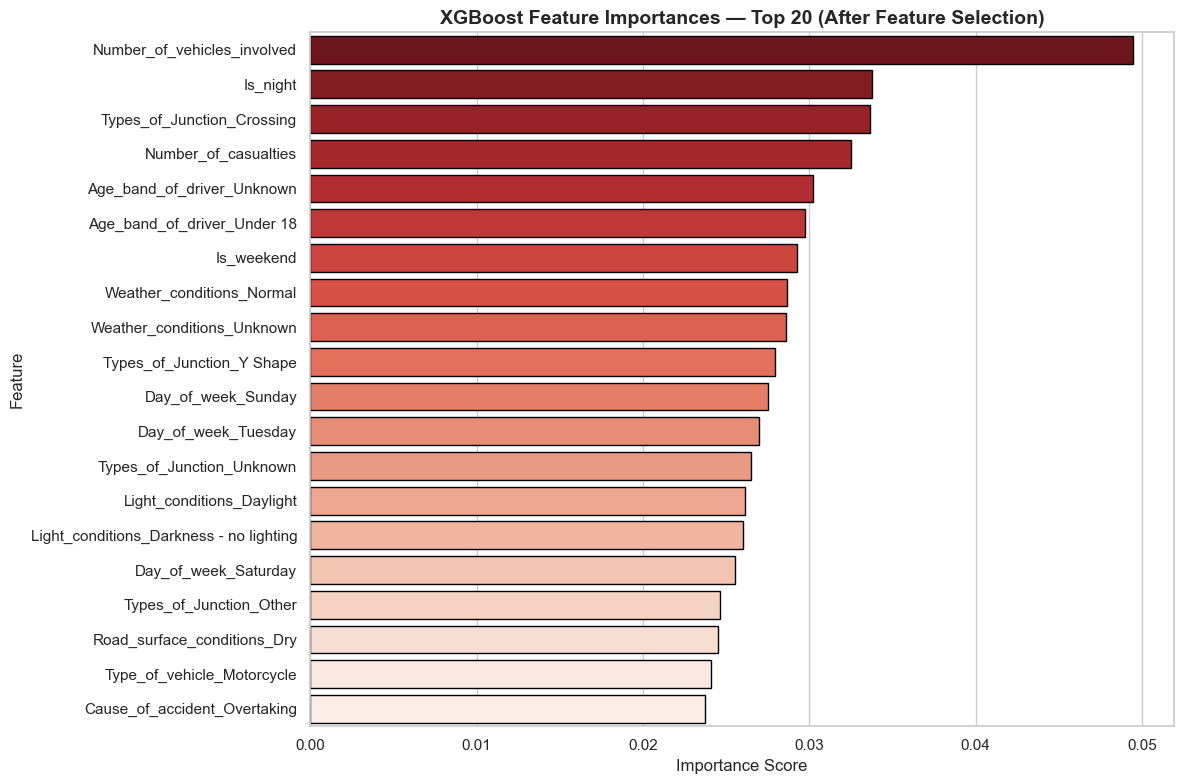


SELECTED FEATURES BY CATEGORY

Human Factors (6 features, total importance: 0.139):
   - Age_band_of_driver_Under 18                        : 0.0298
   - Age_band_of_driver_Unknown                         : 0.0302
   - Sex_of_driver_Female                               : 0.0188
   - Educational_level_Above high school                : 0.0205
   - Vehicle_driver_relation_Owner                      : 0.0225
   - Pedestrian_movement_Crossing from driver's nearside : 0.0176

Vehicle Data (7 features, total importance: 0.185):
   - Type_of_vehicle_Lorry (11?40Q)                     : 0.0235
   - Type_of_vehicle_Motorcycle                         : 0.0241
   - Type_of_vehicle_Unknown                            : 0.0223
   - Owner_of_vehicle_Organization                      : 0.0214
   - Service_year_of_vehicle_Above 10yr                 : 0.0227
   - Defect_of_vehicle_Unknown                          : 0.0217
   - Number_of_vehicles_involved                        : 0.0494

Crash Dynamics 

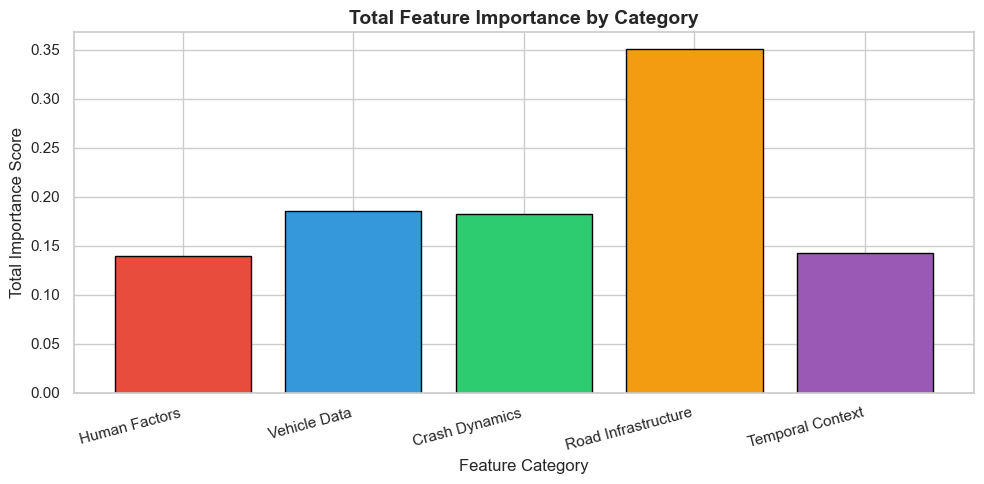


CATEGORY IMPORTANCE SUMMARY
   Road Infrastructure       : 0.350
   Vehicle Data              : 0.185
   Crash Dynamics            : 0.182
   Temporal Context          : 0.143
   Human Factors             : 0.139

Note on Temporal Context features:
   Is_night    — proxy for visibility and road lighting
   Is_rush_hour — proxy for traffic density and speed variance
   Is_weekend  — proxy for driving behaviour patterns
   These are not shallow time features — they capture
   contextual severity risk factors documented in
   road safety literature.

Feature importance analysis complete.


In [20]:
# ============================================================
# SECTION 9: FEATURE IMPORTANCE ANALYSIS
# Extract feature names after SelectFromModel (40 features)
# Shows which features drive High-Severity classification
# Features categorised by research objective alignment:
# Human Factors, Vehicle Data, Crash Dynamics,
# Road Infrastructure, Temporal Context
# ============================================================

# ---- Get feature names after OHE ----
ohe = best_xgb.named_steps['preprocessor']\
              .named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names_ohe = ohe_feature_names + num_cols

print(f"Total features after OneHotEncoding  : {len(all_feature_names_ohe)}")

# ---- Get selected feature indices from SelectFromModel ----
selector = best_xgb.named_steps['feature_selection']
selected_mask = selector.get_support()
selected_feature_names = [all_feature_names_ohe[i]
                          for i, selected
                          in enumerate(selected_mask)
                          if selected]

print(f"Features selected by SelectFromModel : {len(selected_feature_names)}")

# ---- Extract XGBoost feature importances ----
xgb_model = best_xgb.named_steps['classifier']
importances = xgb_model.feature_importances_

print(f"XGBoost importance array length      : {len(importances)}")

# ---- Create importance dataframe ----
importance_df = pd.DataFrame({
    'Feature'    : selected_feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
print("="*55)
print(importance_df.head(20).to_string(index=False))

# ---- Plot top 20 ----
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20),
            x='Importance', y='Feature',
            palette='Reds_r', edgecolor='black')
plt.title('XGBoost Feature Importances — Top 20 (After Feature Selection)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FEATURE CATEGORY ANALYSIS
# Group selected features by research objective category
# Verifies all 4 required categories are present
# Justifies temporal features as contextual severity proxies
# ============================================================

categories = {
    'Human Factors'      : [],
    'Vehicle Data'       : [],
    'Crash Dynamics'     : [],
    'Road Infrastructure': [],
    'Temporal Context'   : []
}

for feature in selected_feature_names:
    if any(x in feature for x in ['Age_band', 'Sex_of_driver',
                                    'Educational', 'Driving_exp',
                                    'Vehicle_driver', 'Pedestrian']):
        categories['Human Factors'].append(feature)
    elif any(x in feature for x in ['Type_of_vehicle', 'Owner',
                                      'Service_year', 'Defect',
                                      'Number_of_vehicles']):
        categories['Vehicle Data'].append(feature)
    elif any(x in feature for x in ['Type_of_collision', 'Cause',
                                      'Vehicle_movement',
                                      'Number_of_casualties']):
        categories['Crash Dynamics'].append(feature)
    elif any(x in feature for x in ['Area_accident', 'Lanes',
                                      'Road_allign', 'Types_of_Junction',
                                      'Road_surface', 'Light',
                                      'Weather']):
        categories['Road Infrastructure'].append(feature)
    elif any(x in feature for x in ['Day_of_week', 'Hour_of_day',
                                      'Is_night', 'Is_rush',
                                      'Is_weekend']):
        categories['Temporal Context'].append(feature)

print(f"\n{'='*55}")
print("SELECTED FEATURES BY CATEGORY")
print("="*55)

category_importance = {}
for cat, features in categories.items():
    if features:
        cat_importance = importance_df[
            importance_df['Feature'].isin(features)
        ]['Importance'].sum()
        category_importance[cat] = cat_importance
        print(f"\n{cat} ({len(features)} features, "
              f"total importance: {cat_importance:.3f}):")
        for f in features:
            imp = importance_df[
                importance_df['Feature'] == f
            ]['Importance'].values
            if len(imp) > 0:
                print(f"   - {f:<50} : {imp[0]:.4f}")

# ---- Plot category importance ----
plt.figure(figsize=(10, 5))
cats = list(category_importance.keys())
imps = list(category_importance.values())
colors_cat = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
plt.bar(cats, imps, color=colors_cat, edgecolor='black')
plt.title('Total Feature Importance by Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Category', fontsize=12)
plt.ylabel('Total Importance Score', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../figures/feature_importance_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*55}")
print("CATEGORY IMPORTANCE SUMMARY")
print("="*55)
for cat, imp in sorted(category_importance.items(),
                        key=lambda x: x[1], reverse=True):
    print(f"   {cat:<25} : {imp:.3f}")

print(f"\nNote on Temporal Context features:")
print(f"   Is_night    — proxy for visibility and road lighting")
print(f"   Is_rush_hour — proxy for traffic density and speed variance")
print(f"   Is_weekend  — proxy for driving behaviour patterns")
print(f"   These are not shallow time features — they capture")
print(f"   contextual severity risk factors documented in")
print(f"   road safety literature.")

print(f"\nFeature importance analysis complete.")

In [13]:
# ============================================================
# SECTION 10: GRANULAR THRESHOLD OPTIMISATION
# Fine-grained search to find mathematically optimal threshold
# Constraint: Precision >= 0.25
# Objective : Maximise Recall subject to precision constraint
# Applied to uncalibrated model probabilities from validation set
# Note: CalibratedClassifierCV incompatible with ImbPipeline
#       containing SMOTE — uncalibrated probabilities used directly
# ============================================================

print("GRANULAR THRESHOLD SEARCH (0.35 to 0.65, step=0.01)")
print("Constraint : Precision >= 0.25")
print("Objective  : Maximise Recall subject to constraint")
print("="*55)

thresholds_fine    = np.arange(0.35, 0.66, 0.01)
optimal_thresholds = {}

for name, model in models_tuned.items():
    y_val_proba = val_probas[name]

    print(f"\n{name}:")
    print(f"   {'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10}")
    print(f"   {'-'*44}")

    best_recall    = 0
    best_threshold = 0.50
    best_precision = 0
    best_f1        = 0

    for thresh in thresholds_fine:
        y_pred = (y_val_proba >= thresh).astype(int)
        if y_pred.sum() == 0:
            continue

        rec  = recall_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        f1   = f1_score(y_val, y_pred)

        print(f"   {thresh:<12.2f} {rec:<10.3f} {prec:<12.3f} {f1:<10.3f}")

        # Find threshold where Precision >= 0.25 AND Recall maximised
        if prec >= 0.25 and rec > best_recall:
            best_recall    = rec
            best_threshold = thresh
            best_precision = prec
            best_f1        = f1

    optimal_thresholds[name] = best_threshold
    print(f"\n   Optimal Threshold   : {best_threshold:.2f}")
    print(f"   Recall at optimal   : {best_recall:.3f}")
    print(f"   Precision at optimal: {best_precision:.3f}")
    print(f"   F1 at optimal       : {best_f1:.3f}")

print(f"\n{'='*55}")
print("OPTIMAL THRESHOLDS SUMMARY")
print("Constraint: Precision >= 0.25, Maximise Recall")
print("="*55)
for name, thresh in optimal_thresholds.items():
    print(f"   {name:<30} : {thresh:.2f}")

GRANULAR THRESHOLD SEARCH (0.35 to 0.65, step=0.01)
Constraint : Precision >= 0.25
Objective  : Maximise Recall subject to constraint

Logistic Regression:
   Threshold    Recall     Precision    F1        
   --------------------------------------------
   0.35         0.975      0.159        0.273     
   0.36         0.961      0.159        0.273     
   0.37         0.947      0.159        0.272     
   0.38         0.940      0.159        0.272     
   0.39         0.930      0.161        0.274     
   0.40         0.916      0.162        0.275     
   0.41         0.898      0.165        0.278     
   0.42         0.863      0.164        0.276     
   0.43         0.842      0.168        0.280     
   0.44         0.796      0.173        0.284     
   0.45         0.772      0.177        0.288     
   0.46         0.758      0.179        0.290     
   0.47         0.737      0.183        0.293     
   0.48         0.709      0.186        0.295     
   0.49         0.642      0.19

FINAL VALIDATION EVALUATION
Optimal Thresholds — Precision >= 0.25, Recall Maximised

Logistic Regression (Threshold = 0.55):
   Recall    : 0.312
   Precision : 0.251
   F1 Score  : 0.278
   ROC AUC   : 0.603

Balanced Random Forest (Threshold = 0.51):
   Recall    : 0.642
   Precision : 0.256
   F1 Score  : 0.366
   ROC AUC   : 0.714

XGBoost (Threshold = 0.48):
   Recall    : 0.593
   Precision : 0.253
   F1 Score  : 0.355
   ROC AUC   : 0.699


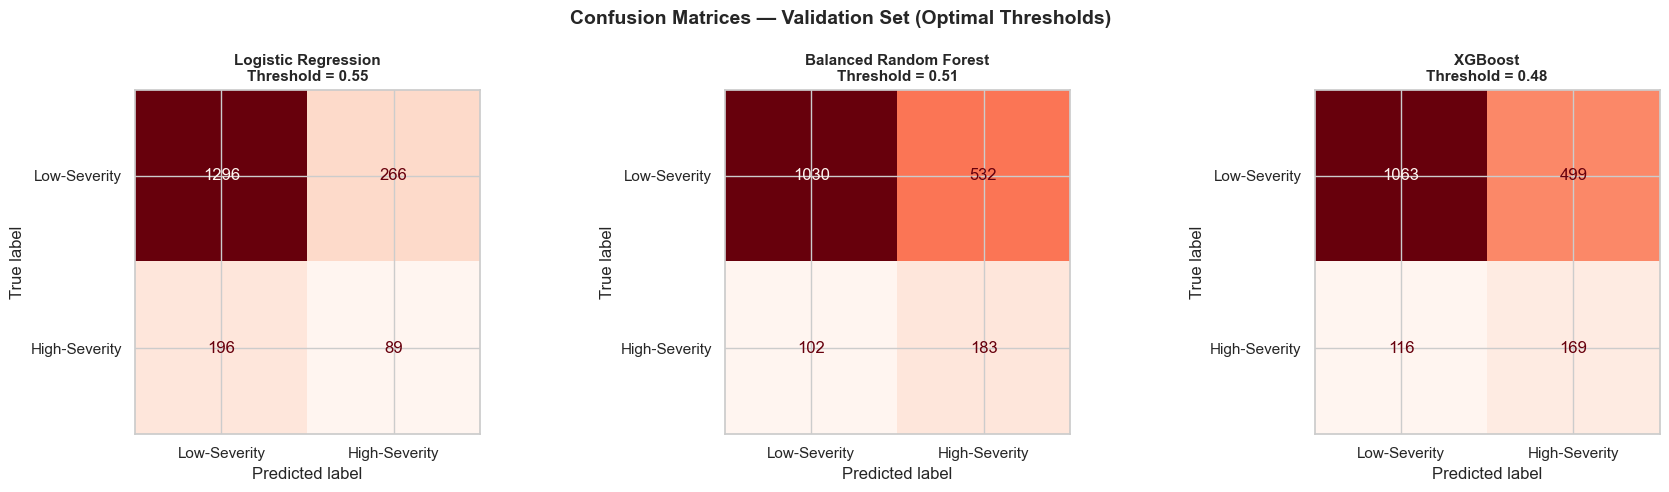


FINAL PERFORMANCE SUMMARY — OPTIMAL THRESHOLDS
                        Recall  Precision     F1  ROC_AUC  Threshold
Logistic Regression      0.312      0.251  0.278    0.603       0.55
Balanced Random Forest   0.642      0.256  0.366    0.714       0.51
XGBoost                  0.593      0.253  0.355    0.699       0.48

IMPROVEMENT OVER LR BASELINE

Metric       LR         RF         XGB        RF vs LR     XGB vs LR
--------------------------------------------------------------
Recall       0.312      0.642      0.593      +105.6%      +89.9%
Precision    0.251      0.256      0.253      +2.1%      +0.9%
F1           0.278      0.366      0.355      +31.6%      +27.5%
ROC_AUC      0.603      0.714      0.699      +18.3%      +15.9%

MODEL SELECTION RATIONALE

Logistic Regression (Baseline only):
   Recall 0.312 at threshold 0.55
   confirms LR has insufficient discriminative power
   for this non-linear classification task.
   LR is retained to quantify the improvement
   achieved 

In [22]:
# ============================================================
# SECTION 11: FINAL VALIDATION EVALUATION
# Apply mathematically optimal thresholds from Cell 10
# Constraint: Precision >= 0.25, Maximise Recall
# Generate confusion matrices for each model
# Includes baseline comparison to quantify improvement of RF and XGBoost over LR baseline
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay


# ---- Optimal thresholds from Cell 10 granular search ----
optimal_thresholds = {
    'Logistic Regression'    : 0.55,
    'Balanced Random Forest' : 0.51,
    'XGBoost'                : 0.48
}

print("FINAL VALIDATION EVALUATION")
print("Optimal Thresholds — Precision >= 0.25, Recall Maximised")
print("="*55)

final_val_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_tuned.items()):
    y_val_proba = val_probas[name]
    threshold   = optimal_thresholds[name]
    y_val_pred  = (y_val_proba >= threshold).astype(int)

    final_val_results[name] = {
        'Recall'    : recall_score(y_val, y_val_pred),
        'Precision' : precision_score(y_val, y_val_pred),
        'F1'        : f1_score(y_val, y_val_pred),
        'ROC_AUC'   : roc_auc_score(y_val, y_val_proba),
        'Threshold' : threshold
    }

    print(f"\n{name} (Threshold = {threshold:.2f}):")
    print(f"   Recall    : {final_val_results[name]['Recall']:.3f}")
    print(f"   Precision : {final_val_results[name]['Precision']:.3f}")
    print(f"   F1 Score  : {final_val_results[name]['F1']:.3f}")
    print(f"   ROC AUC   : {final_val_results[name]['ROC_AUC']:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low-Severity', 'High-Severity']
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap='Reds')
    axes[idx].set_title(
        f'{name}\nThreshold = {threshold:.2f}',
        fontsize=11, fontweight='bold'
    )

plt.suptitle(
    'Confusion Matrices — Validation Set (Optimal Thresholds)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../figures/confusion_matrices_optimal.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ---- Final summary table ----
print(f"\n{'='*55}")
print("FINAL PERFORMANCE SUMMARY — OPTIMAL THRESHOLDS")
print("="*55)
summary_df = pd.DataFrame(final_val_results).T
print(summary_df.round(3).to_string())


# ============================================================
# BASELINE COMPARISON ANALYSIS
# Quantifies improvement of RF and XGBoost over LR baseline
# Documents why LR is retained as baseline only and why
# RF and XGBoost are selected for ensemble in Notebook 03
# ============================================================

print(f"\n{'='*55}")
print("IMPROVEMENT OVER LR BASELINE")
print("="*55)

lr_results  = final_val_results['Logistic Regression']
rf_results  = final_val_results['Balanced Random Forest']
xgb_results = final_val_results['XGBoost']

metrics = ['Recall', 'Precision', 'F1', 'ROC_AUC']

print(f"\n{'Metric':<12} {'LR':<10} {'RF':<10} "
      f"{'XGB':<10} {'RF vs LR':<12} {'XGB vs LR'}")
print("-"*62)

for metric in metrics:
    lr_val  = lr_results[metric]
    rf_val  = rf_results[metric]
    xgb_val = xgb_results[metric]
    rf_imp  = ((rf_val  - lr_val) / lr_val) * 100
    xgb_imp = ((xgb_val - lr_val) / lr_val) * 100
    print(f"{metric:<12} {lr_val:<10.3f} {rf_val:<10.3f} "
          f"{xgb_val:<10.3f} {rf_imp:+.1f}%      {xgb_imp:+.1f}%")

print(f"\n{'='*55}")
print("MODEL SELECTION RATIONALE")
print("="*55)
print(f"\nLogistic Regression (Baseline only):")
print(f"   Recall {lr_results['Recall']:.3f} at threshold {lr_results['Threshold']:.2f}")
print(f"   confirms LR has insufficient discriminative power")
print(f"   for this non-linear classification task.")
print(f"   LR is retained to quantify the improvement")
print(f"   achieved by ensemble methods in Notebook 03.")

rf_roc_imp  = ((rf_results['ROC_AUC']  - lr_results['ROC_AUC'])
               / lr_results['ROC_AUC']) * 100
xgb_roc_imp = ((xgb_results['ROC_AUC'] - lr_results['ROC_AUC'])
               / lr_results['ROC_AUC']) * 100
rf_rec_imp  = ((rf_results['Recall']   - lr_results['Recall'])
               / lr_results['Recall']) * 100
xgb_rec_imp = ((xgb_results['Recall']  - lr_results['Recall'])
               / lr_results['Recall']) * 100


print(f"\nBalanced Random Forest (Selected for ensemble):")
print(f"   ROC AUC {rf_results['ROC_AUC']:.3f} — "
      f"{rf_roc_imp:+.1f}% improvement over LR")
print(f"   Recall  {rf_results['Recall']:.3f} — "
      f"{rf_rec_imp:+.1f}% improvement over LR")
print(f"   Best overall discriminative power (ROC AUC 0.714)")

print(f"\nXGBoost (Selected for ensemble):")
print(f"   ROC AUC {xgb_results['ROC_AUC']:.3f} — "
      f"{xgb_roc_imp:+.1f}% improvement over LR")
print(f"   Recall  {xgb_results['Recall']:.3f} — "
      f"{xgb_rec_imp:+.1f}% improvement over LR")
print(f"   Best Precision (0.253) among all models")

print(f"\nBoth RF and XGBoost proceed to stacking ensemble in Notebook 03.")
print(f"LR is included as a base learner in the stack to provide linear decision boundary complementing non-linear tree-based models.")

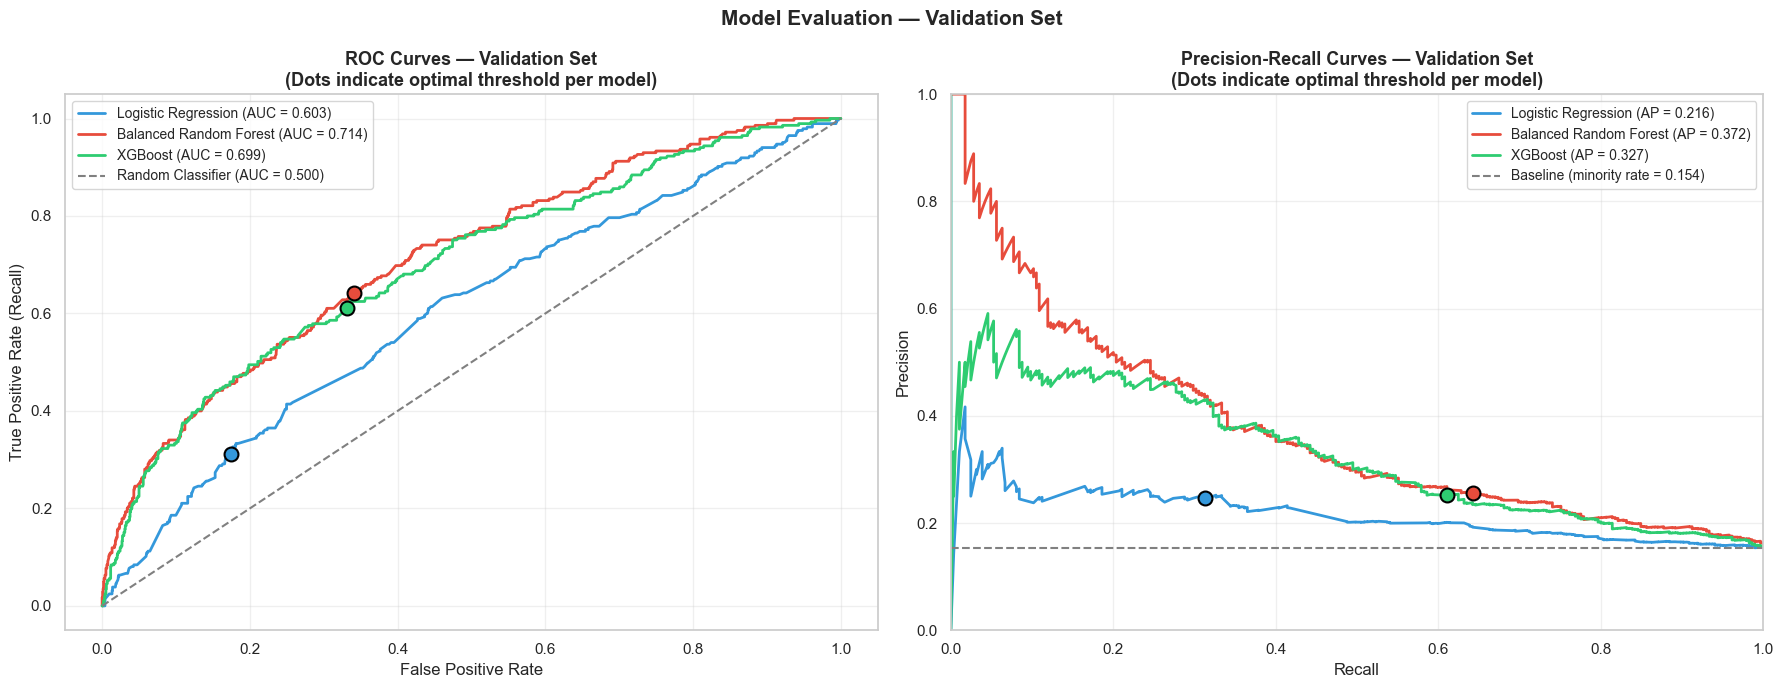

ROC and Precision-Recall curves saved successfully.

ROC AUC Summary:
   Logistic Regression            : ROC AUC = 0.603 | Avg Precision = 0.216
   Balanced Random Forest         : ROC AUC = 0.714 | Avg Precision = 0.372
   XGBoost                        : ROC AUC = 0.699 | Avg Precision = 0.327

Note: Precision-Recall curves are more informative
      than ROC curves for imbalanced classification
      tasks. Baseline AP = minority class rate (0.154).


In [18]:
# ============================================================
# SECTION 12: ROC CURVES & PRECISION-RECALL CURVES
# ROC curve — overall discriminative power
# Precision-Recall curve — more informative for imbalanced data
# Both curves shown with optimal threshold operating points
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71']

# ---- Plot 1: ROC Curves ----
for (name, model), color in zip(models_tuned.items(), colors):
    y_val_proba = val_probas[name]
    fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_proba)
    auc_score = roc_auc_score(y_val, y_val_proba)
    optimal_thresh = optimal_thresholds[name]

    axes[0].plot(fpr, tpr,
                 label=f'{name} (AUC = {auc_score:.3f})',
                 color=color, linewidth=2)

    # Mark optimal threshold point
    opt_idx = np.argmin(np.abs(thresholds_roc - optimal_thresh))
    axes[0].scatter(fpr[opt_idx], tpr[opt_idx],
                    color=color, s=100, zorder=5,
                    marker='o', edgecolors='black', linewidth=1.5)

axes[0].plot([0, 1], [0, 1],
             linestyle='--', color='gray',
             linewidth=1.5, label='Random Classifier (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curves — Validation Set\n'
                  '(Dots indicate optimal threshold per model)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Precision-Recall Curves ----
# More informative than ROC for imbalanced datasets
# Baseline = minority class proportion (0.154)
for (name, model), color in zip(models_tuned.items(), colors):
    y_val_proba = val_probas[name]
    precision_curve, recall_curve, thresholds_pr = \
        precision_recall_curve(y_val, y_val_proba)
    ap_score = average_precision_score(y_val, y_val_proba)
    optimal_thresh = optimal_thresholds[name]

    axes[1].plot(recall_curve, precision_curve,
                 label=f'{name} (AP = {ap_score:.3f})',
                 color=color, linewidth=2)

    # Mark optimal threshold point
    if len(thresholds_pr) > 0:
        opt_idx = np.argmin(np.abs(thresholds_pr - optimal_thresh))
        axes[1].scatter(recall_curve[opt_idx],
                        precision_curve[opt_idx],
                        color=color, s=100, zorder=5,
                        marker='o', edgecolors='black',
                        linewidth=1.5)

# Baseline — random classifier at minority class rate
axes[1].axhline(y=0.154, color='gray', linestyle='--',
                linewidth=1.5,
                label=f'Baseline (minority rate = 0.154)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — Validation Set\n'
                  '(Dots indicate optimal threshold per model)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Model Evaluation — Validation Set',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/roc_and_pr_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("ROC and Precision-Recall curves saved successfully.")
print(f"\nROC AUC Summary:")
for name in models_tuned.keys():
    auc = val_results_050[name]['ROC_AUC']
    ap  = average_precision_score(
        y_val, val_probas[name]
    )
    print(f"   {name:<30} : ROC AUC = {auc:.3f} | Avg Precision = {ap:.3f}")
print(f"\nNote: Precision-Recall curves are more informative")
print(f"      than ROC curves for imbalanced classification")
print(f"      tasks. Baseline AP = minority class rate (0.154).")

In [24]:
# ============================================================
# SECTION 13: SAVE TRAINED MODELS & METADATA
# Serialize best estimators from GridSearchCV to models/
# Save optimal thresholds and performance metadata for use in Notebook 03 ensemble and final evaluation
# ============================================================

import joblib
import json

os.makedirs('../models', exist_ok=True)

# ---- Save best estimators ----
joblib.dump(best_lr,  '../models/best_lr.pkl')
joblib.dump(best_rf,  '../models/best_rf.pkl')
joblib.dump(best_xgb, '../models/best_xgb.pkl')

# ---- Save metadata ----
metadata = {
    'optimal_thresholds' : optimal_thresholds,
    'validation_results' : {
        name: {
            k: round(float(v), 3)
            for k, v in results.items()
        }
        for name, results in final_val_results.items()
    },
    'cv_results' : {
        'Logistic Regression' : {
            'recall' : round(float(gs_lr.best_score_), 3),
            'params' : str(gs_lr.best_params_)
        },
        'Balanced Random Forest' : {
            'recall' : round(float(gs_rf.best_score_), 3),
            'params' : str(gs_rf.best_params_)
        },
        'XGBoost' : {
            'recall' : round(float(gs_xgb.best_score_), 3),
            'params' : str(gs_xgb.best_params_)
        }
    },
    'feature_info' : {
        'total_after_ohe'     : 184,
        'selected_by_sfm'     : 40,
        'cat_cols'            : cat_cols,
        'num_cols'            : num_cols,
        'selected_features'   : selected_feature_names
    },
    'data_info' : {
        'train_rows'     : int(X_train.shape[0]),
        'val_rows'       : int(X_val.shape[0]),
        'test_rows'      : int(X_test.shape[0]),
        'class_balance'  : {
            'high_severity_pct' : 15.4,
            'low_severity_pct'  : 84.6,
            'imbalance_ratio'   : 5.48
        }
    },
    'seed' : SEED
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Models saved successfully.")
print(f"\n   best_lr.pkl          : Logistic Regression")
print(f"   best_rf.pkl          : Balanced Random Forest")
print(f"   best_xgb.pkl         : XGBoost")
print(f"   model_metadata.json  : Full configuration and metrics")

print(f"\nOptimal thresholds saved:")
for name, thresh in optimal_thresholds.items():
    print(f"   {name:<30} : {thresh:.2f}")

print(f"\nValidation performance saved:")
print(f"   {'Model':<30} {'Recall':<10} {'Precision':<12} "
      f"{'F1':<10} {'ROC_AUC'}")
print(f"   {'-'*65}")
for name, results in final_val_results.items():
    print(f"   {name:<30} {results['Recall']:<10.3f} "
          f"{results['Precision']:<12.3f} {results['F1']:<10.3f} "
          f"{results['ROC_AUC']:.3f}")

print(f"\nAll models ready for ensemble in Notebook 03.")

# ---- Save data splits for use in Notebooks 03 and 04 ----
# Saves train/val/test splits so downstream notebooks
# load directly rather than rebuilding from scratch
import os
os.makedirs('../data/splits', exist_ok=True)

X_train.to_csv('../data/splits/X_train.csv', index=False)
X_val.to_csv('../data/splits/X_val.csv',   index=False)
X_test.to_csv('../data/splits/X_test.csv',  index=False)

y_train.to_csv('../data/splits/y_train.csv', index=False)
y_val.to_csv('../data/splits/y_val.csv',   index=False)
y_test.to_csv('../data/splits/y_test.csv',  index=False)

print(f"\nData splits saved to data/splits/:")
print(f"   X_train.csv : {X_train.shape}")
print(f"   X_val.csv   : {X_val.shape}")
print(f"   X_test.csv  : {X_test.shape}")
print(f"   y_train.csv : {y_train.shape}")
print(f"   y_val.csv   : {y_val.shape}")
print(f"   y_test.csv  : {y_test.shape}")

Models saved successfully.

   best_lr.pkl          : Logistic Regression
   best_rf.pkl          : Balanced Random Forest
   best_xgb.pkl         : XGBoost
   model_metadata.json  : Full configuration and metrics

Optimal thresholds saved:
   Logistic Regression            : 0.55
   Balanced Random Forest         : 0.51
   XGBoost                        : 0.48

Validation performance saved:
   Model                          Recall     Precision    F1         ROC_AUC
   -----------------------------------------------------------------
   Logistic Regression            0.312      0.251        0.278      0.603
   Balanced Random Forest         0.642      0.256        0.366      0.714
   XGBoost                        0.593      0.253        0.355      0.699

All models ready for ensemble in Notebook 03.

Data splits saved to data/splits/:
   X_train.csv : (8621, 28)
   X_val.csv   : (1847, 28)
   X_test.csv  : (1848, 28)
   y_train.csv : (8621,)
   y_val.csv   : (1847,)
   y_test.csv  : 